In [38]:
# Cell 2 (Perbaikan): Setup API Keys & Inisialisasi Model
import os
import pandas as pd
from dotenv import load_dotenv

# Muat environment variables dari file .env
load_dotenv()

# Pastikan API key Anda sudah ter-set
if not os.getenv("OPENROUTER_API_KEY"):
    print("❌ OPENROUTER_API_KEY tidak ditemukan. Harap atur di file .env Anda.")
else:
    print("✅ OpenRouter API Key siap digunakan.")

# Konfigurasi LLM yang akan digunakan oleh RAGAS untuk melakukan evaluasi
from langchain_openai import ChatOpenAI
# --- PERUBAHAN DI SINI ---
# Mengimpor kelas wrapper yang baru dari ragas.llms.base
from ragas.llms.base import LangchainLLMWrapper

# Inisialisasi LLM dari OpenRouter (tidak berubah)
openrouter_llm = ChatOpenAI(
    model="google/gemini-2.5-pro",
    temperature=0, # Suhu 0 untuk evaluasi yang lebih deterministik
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url=os.getenv("OPENROUTER_BASE_URL"),
    default_headers={
        "HTTP-Referer": "http://localhost:8888", # Sesuaikan jika perlu
        "X-Title": "RAG Evaluation Notebook",
    }
)

# --- PERUBAHAN DI SINI ---
# Bungkus LLM untuk digunakan oleh RAGAS menggunakan kelas yang baru
# Perhatikan parameter 'langchain_llm'
ragas_llm = LangchainLLMWrapper(langchain_llm=openrouter_llm)


print("👍 Konfigurasi LLM untuk RAGAS selesai.")

✅ OpenRouter API Key siap digunakan.
👍 Konfigurasi LLM untuk RAGAS selesai.


In [39]:
# Cell 3: Memuat Dataset
import pandas as pd

data = {
    'question': [
        "Apa hak dan kewajiban sebagai pasien?",
        "Apa syarat melakukan transplantasi organ?",
        "Apa sanksi jika mengedarkan narkotika secara ilegal?"
    ],
    'answer': [ # Kolom ini berisi jawaban dari chatbot Anda
        "Hak dan kewajiban pasien diatur dalam Pasal 276 dan 277. Hak pasien mencakup informasi tentang kesehatan dirinya dan pelayanan yang sesuai standar. Kewajiban pasien adalah memberi info yang lengkap dan jujur serta mematuhi ketentuan di faskes.",
        "Syarat transplantasi organ adalah adanya donor yang bersedia, dilakukan di rumah sakit yang memiliki izin, dan tidak untuk tujuan komersial. Baik pendonor maupun resipien harus memberikan consent.",
        "Mengedarkan narkotika secara ilegal akan dikenakan sanksi pidana penjara. Hukumannya bisa sangat berat, tergantung pada jenis dan jumlah narkotika yang diedarkan."
    ],
    'ground_truth': [ # Kolom ini berisi jawaban referensi/ideal
        "Menurut Pasal 276 dan 277, hak pasien meliputi mendapatkan informasi kesehatan, penjelasan memadai, dan pelayanan yang bermutu. Kewajiban pasien adalah memberikan informasi yang jujur, mematuhi nasihat tenaga medis, dan memberikan imbalan jasa.",
        "Transplantasi organ hanya dapat dilakukan atas persetujuan tertulis dari pendonor dan penerima, setelah mendapatkan penjelasan medis. Tindakan ini harus dilakukan oleh tim dokter ahli di fasilitas kesehatan yang ditunjuk oleh Menteri.",
        "Setiap orang yang tanpa hak atau melawan hukum mengedarkan narkotika golongan I dapat dipidana dengan pidana penjara seumur hidup atau pidana penjara paling singkat 5 tahun dan paling lama 20 tahun serta denda minimal 1 miliar rupiah."
    ],
    'contexts': [ # Ini adalah konteks yang di-retrieve oleh sistem RAG Anda
        ["Pasal 276 menyatakan bahwa setiap pasien berhak mendapatkan informasi yang benar dan jelas tentang kondisi kesehatannya. Pasal 277 menambahkan bahwa pasien berkewajiban untuk memberikan informasi yang jujur, lengkap, dan akurat mengenai masalah kesehatannya serta mematuhi tata tertib dan peraturan di fasilitas pelayanan kesehatan."],
        ["Persetujuan dari pendonor dan penerima (resipien) yang dilakukan secara sadar dan tanpa paksaan adalah syarat mutlak untuk transplantasi. Prosedur ini tidak boleh dimotivasi oleh keuntungan finansial dan harus dilaksanakan di fasilitas kesehatan yang ditunjuk oleh pemerintah untuk menjamin keamanan dan kualitas."],
        ["Undang-undang Narkotika mengatur sanksi pidana yang berat bagi pengedar. Hukuman yang diberikan bersifat berjenjang, mempertimbangkan golongan narkotika dan volume barang bukti. Untuk golongan I, sanksinya bisa mencapai pidana mati atau penjara seumur hidup."]
    ]
}

df = pd.DataFrame(data)
print("📄 Dataset berhasil dimuat:")
display(df)

📄 Dataset berhasil dimuat:


,question,answer,ground_truth,contexts
0,Apa hak dan kewajiban sebagai pasien?,Hak dan kewajiban pasien diatur dalam Pasal 27...,"Menurut Pasal 276 dan 277, hak pasien meliputi...",[Pasal 276 menyatakan bahwa setiap pasien berh...
1,Apa syarat melakukan transplantasi organ?,Syarat transplantasi organ adalah adanya donor...,Transplantasi organ hanya dapat dilakukan atas...,[Persetujuan dari pendonor dan penerima (resip...
2,Apa sanksi jika mengedarkan narkotika secara i...,Mengedarkan narkotika secara ilegal akan diken...,Setiap orang yang tanpa hak atau melawan hukum...,[Undang-undang Narkotika mengatur sanksi pidan...


In [42]:
# Cell 4: Menghitung ROUGE
from rouge_score import rouge_scorer

# Inisialisasi scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Fungsi untuk menghitung skor dan menambahkannya ke DataFrame
def calculate_rouge(row):
    scores = scorer.score(row['ground_truth'], row['answer'])
    row['rouge1_f1'] = scores['rouge1'].fmeasure
    row['rouge2_f1'] = scores['rouge2'].fmeasure
    row['rougeL_f1'] = scores['rougeL'].fmeasure
    return row

# Terapkan fungsi ke setiap baris DataFrame
df_rouge = df.apply(calculate_rouge, axis=1)

print("📊 Hasil ROUGE Score (F1-Score):")
display(df_rouge[['question', 'rouge1_f1', 'rouge2_f1', 'rougeL_f1']])

📊 Hasil ROUGE Score (F1-Score):


,question,rouge1_f1,rouge2_f1,rougeL_f1
0,Apa hak dan kewajiban sebagai pasien?,0.529412,0.272727,0.500000
1,Apa syarat melakukan transplantasi organ?,0.275862,0.035714,0.172414
2,Apa sanksi jika mengedarkan narkotika secara i...,0.206897,0.071429,0.172414


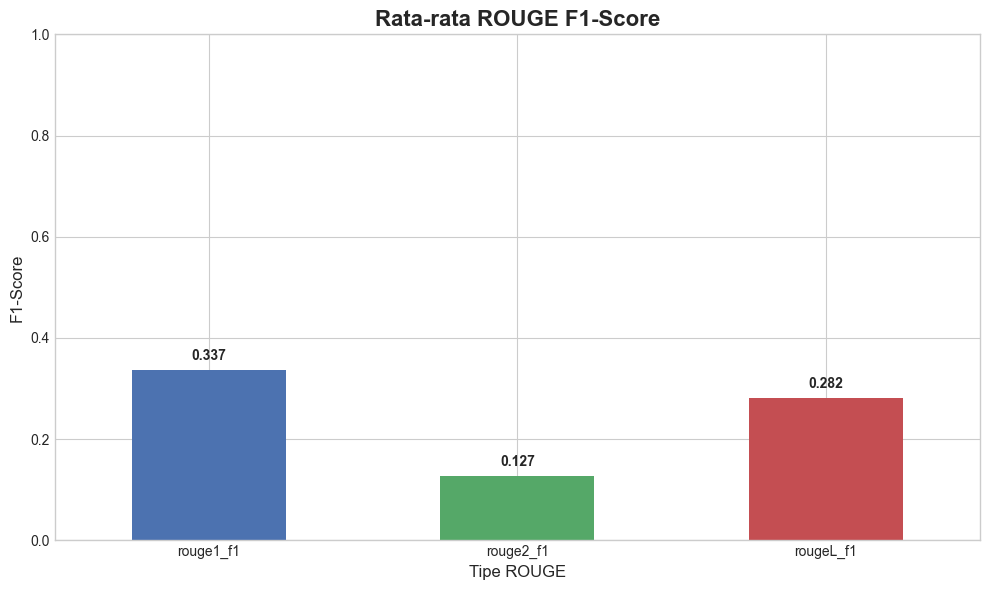

In [43]:
# Cell 5: Visualisasi ROUGE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Menghitung rata-rata skor
avg_scores = df_rouge[['rouge1_f1', 'rouge2_f1', 'rougeL_f1']].mean()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

avg_scores.plot(kind='bar', ax=ax, color=['#4c72b0', '#55a868', '#c44e52'])
ax.set_title('Rata-rata ROUGE F1-Score', fontsize=16, fontweight='bold')
ax.set_xlabel('Tipe ROUGE', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_xticklabels(avg_scores.index, rotation=0)
ax.set_ylim(0, 1)

# Menambahkan label pada bar
for i, v in enumerate(avg_scores):
    ax.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [44]:
# Cell 6: Menghitung BERTScore
from bert_score import score

# Ambil list dari jawaban prediksi dan referensi
predictions = df['answer'].tolist()
references = df['ground_truth'].tolist()

# Hitung BERTScore
# Kita menggunakan model multilingual karena datanya Bahasa Indonesia
P, R, F1 = score(predictions, references, lang='id', verbose=True)

# Tambahkan F1-score ke DataFrame
df_bert = df_rouge.copy() # Salin dari dataframe sebelumnya
df_bert['bert_score_f1'] = F1.numpy()

print("\n📊 Hasil BERTScore (F1-Score):")
display(df_bert[['question', 'bert_score_f1']])

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 1.47 seconds, 2.05 sentences/sec

📊 Hasil BERTScore (F1-Score):


,question,bert_score_f1
0,Apa hak dan kewajiban sebagai pasien?,0.822286
1,Apa syarat melakukan transplantasi organ?,0.734355
2,Apa sanksi jika mengedarkan narkotika secara i...,0.721143


C:\Users\Asus\AppData\Local\Temp\ipykernel_20196\102936599.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.arange(len(df_bert)), y=df_bert['bert_score_f1'], ax=ax, palette='viridis')


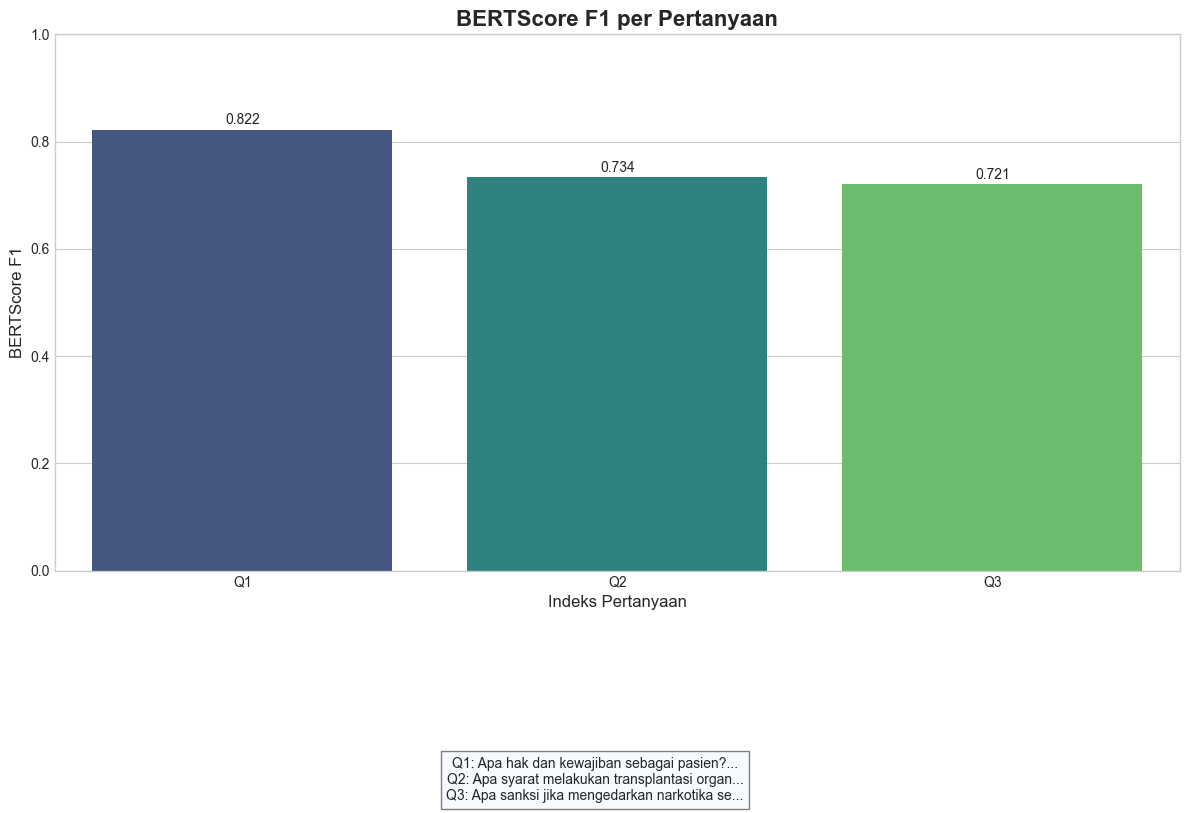

In [45]:
# Cell 7: Visualisasi BERTScore
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(x=np.arange(len(df_bert)), y=df_bert['bert_score_f1'], ax=ax, palette='viridis')
ax.set_title('BERTScore F1 per Pertanyaan', fontsize=16, fontweight='bold')
ax.set_ylabel('BERTScore F1', fontsize=12)
ax.set_xlabel('Indeks Pertanyaan', fontsize=12)
ax.set_xticks(np.arange(len(df_bert)))
ax.set_xticklabels([f"Q{i+1}" for i in range(len(df_bert))], rotation=0)
ax.set_ylim(0, 1)

# Menambahkan label pada bar
for index, value in enumerate(df_bert['bert_score_f1']):
    ax.text(index, value + 0.01, f"{value:.3f}", ha='center')

# Menambahkan legenda pertanyaan di bawah plot
question_legend = "\n".join([f"Q{i+1}: {q[:40]}..." for i, q in enumerate(df_bert['question'])])
fig.text(0.5, -0.15, question_legend, ha='center', fontsize=10, bbox=dict(facecolor='aliceblue', alpha=0.5))


plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()